In [1]:
#prepare indputs for mt pasa solve

In [1]:
# 30 minute actual demand and rooftop PV 2019 to 2025 for 5 regions
#interval datetime, regionID, demand, rooftop_PV


import time
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path
import datetime
import os
from datetime import datetime
from zoneinfo import ZoneInfo

regions = ['NSW1','QLD1','SA1','TAS1','VIC1']

base = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/New_model/mt_pasa/")

df_demand = pd.read_csv(base / "NEM_DEMAND_ROOFTOP_FY.csv") # ensures FY match with wind solar ISP traces
df_demand["INTERVAL_DATETIME"] = pd.to_datetime(df_demand["INTERVAL_DATETIME"],format = "%d/%m/%Y %H:%M")
df_demand['Month'] = df_demand['INTERVAL_DATETIME'].dt.month
df_demand["REF_YEAR"] = (df_demand["INTERVAL_DATETIME"].dt.year + (df_demand["Month"] >= 7))
df_demand['Day'] = df_demand['INTERVAL_DATETIME'].dt.day
df_demand['Hour'] = df_demand['INTERVAL_DATETIME'].dt.hour
df_demand['Minute'] = df_demand['INTERVAL_DATETIME'].dt.minute

for r in regions:
    df_demand[r+"_DEM_GROSS"] = df_demand[r+" TOTALDEMAND"] + df_demand[r+" ROOFTOP"]   

df_demand = df_demand[df_demand['REF_YEAR'] != 2026] # redundant

# Average demand by year and hour
monthly_avg = (df_demand.groupby(['REF_YEAR', 'Month'])[[f'{r}_DEM_GROSS' for r in regions]].mean().reset_index())

#add an estimate of 2026 average
pred_rows = []
for month in range(1, 13):
    month_df = monthly_avg[monthly_avg['Month'] == month]
    row = {'REF_YEAR': 2026,'Month': month}
    
    for region in regions:
        start = month_df.loc[month_df['REF_YEAR'] == 2019, region+'_DEM_GROSS'].iloc[0]
        end = month_df.loc[month_df['REF_YEAR'] == 2025, region+'_DEM_GROSS'].iloc[0]

        cagr = (end / start) ** (1 / 6) - 1 #  CAGR
        #print(cagr*100)
        #test.append(cagr)
        row[region] = end * (1 + cagr)

    pred_rows.append(row)

df_2026 = pd.DataFrame(pred_rows)

#df_2026

#demand_cols = [r + ' TOTALDEMAND' for r in regions]

df_2026 = df_2026.drop(columns=["REF_YEAR"])

monthly_avg = pd.merge(monthly_avg,df_2026,on=['Month'],how='left')
for r in regions:
    monthly_avg[r]= monthly_avg[r] / monthly_avg[r+'_DEM_GROSS'] 


demand_scalers = monthly_avg[['REF_YEAR','Month']+regions]
#demand_scalers
df_demand = pd.merge(df_demand,demand_scalers,on=['REF_YEAR','Month'],how='left')

for r in regions:
    df_demand[r+"_DEM_GROSS"] = df_demand[r+"_DEM_GROSS"] * df_demand[r]

df_demand = df_demand[['INTERVAL_DATETIME','REF_YEAR','Month','Day','Hour','Minute']+[r + '_DEM_GROSS' for r in regions]+[r + ' ROOFTOP' for r in regions]]

# now do solar correction
rooftop_cols = [r + ' ROOFTOP' for r in regions]

#get monthly maximum
df_rooftop_max = (df_demand.groupby(['REF_YEAR', 'Month'])[rooftop_cols].mean().reset_index())
#remove 2026
df_rooftop_max = df_rooftop_max[df_rooftop_max['REF_YEAR'] != 2026]

#add an estimate of 2026 maximums
pred_rows = []
for month in range(1, 13):
    month_df = df_rooftop_max[df_rooftop_max['Month'] == month]
    row = {'REF_YEAR': 2026,'Month': month}
    
    for region in regions:
        start = month_df.loc[month_df['REF_YEAR'] == 2023, region+' ROOFTOP'].iloc[0]
        end = month_df.loc[month_df['REF_YEAR'] == 2025, region+' ROOFTOP'].iloc[0]

        cagr = (end / start) ** (1 / 2) - 1 # two year recent CAGR
        #print(cagr)
        #test.append(cagr)
        row[region+' ROOFTOP'] = end * (1 + cagr)

    pred_rows.append(row)

df_2026 = pd.DataFrame(pred_rows)

df_rooftop_max = pd.concat([df_rooftop_max, df_2026], ignore_index=True)
#df_rooftop_max.to_csv(base / 'test.csv',index=False) 

#add the 2026 max rooftop PV to all years 
ref_2026 = (df_rooftop_max[df_rooftop_max['REF_YEAR'] == 2026].set_index('Month')[rooftop_cols])
joined = df_rooftop_max.merge(ref_2026.reset_index(),on='Month',suffixes=('', '_2026'))
# Calculate scale factors with 2026 as the basis
for col in rooftop_cols:
    joined[col.split()[0]] = joined[f'{col}_2026'] / joined[col]
joined = joined[['REF_YEAR','Month']+regions]

df_demand = pd.merge(df_demand,joined,on=['REF_YEAR','Month'],how='left')
#df_demand.to_csv(base / 'test.csv',index=False)
for r in regions:
    df_demand[r+"_DEM_GROSS"] = df_demand[r+"_DEM_GROSS"]  - df_demand[r+" ROOFTOP"] *  df_demand[r]  
df_demand = df_demand[['INTERVAL_DATETIME','REF_YEAR','Month','Day','Hour','Minute']+[r + '_DEM_GROSS' for r in regions]]

demand_cols = ['NSW1_DEM_GROSS','QLD1_DEM_GROSS','SA1_DEM_GROSS','TAS1_DEM_GROSS','VIC1_DEM_GROSS']

df_long = df_demand.melt(
    id_vars=['INTERVAL_DATETIME', 'REF_YEAR', 'Month', 'Day', 'Hour', 'Minute'],
    value_vars=demand_cols,
    var_name='REGIONID',
    value_name='DEMAND50'
)
df_long['REGIONID'] = df_long['REGIONID'].str.removesuffix('_DEM_GROSS')

df_long.to_parquet(base /"demand_traces_x7.parquet", index=False)

df_long



,INTERVAL_DATETIME,REF_YEAR,Month,Day,Hour,Minute,REGIONID,DEMAND50
0,2018-07-01 00:00:00,2019,7,1,0,0,NSW1,8613.378104
1,2018-07-01 00:30:00,2019,7,1,0,30,NSW1,8613.378104
2,2018-07-01 01:00:00,2019,7,1,1,0,NSW1,8361.709414
3,2018-07-01 01:30:00,2019,7,1,1,30,NSW1,8161.930521
4,2018-07-01 02:00:00,2019,7,1,2,0,NSW1,7925.176708
...,...,...,...,...,...,...,...,...
613675,2025-06-30 21:30:00,2025,6,30,21,30,VIC1,7141.368772
613676,2025-06-30 22:00:00,2025,6,30,22,0,VIC1,6701.896315
613677,2025-06-30 22:30:00,2025,6,30,22,30,VIC1,6423.537580
613678,2025-06-30 23:00:00,2025,6,30,23,0,VIC1,6142.078151


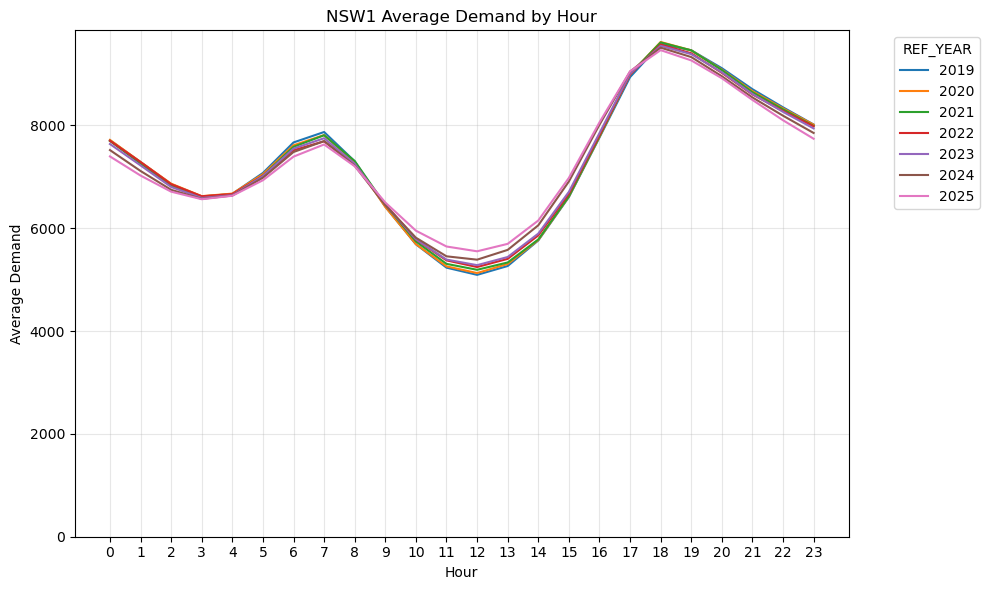

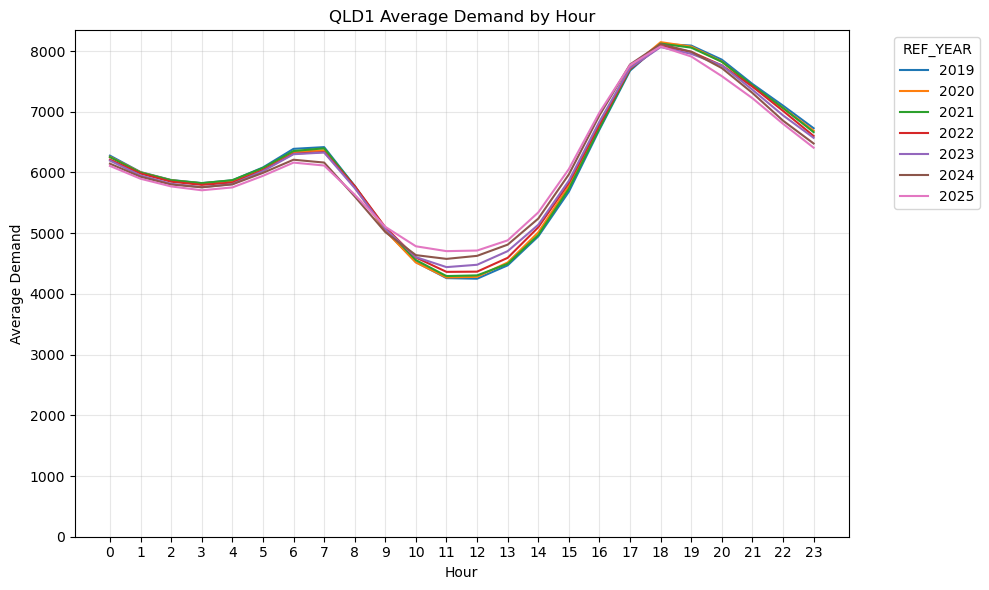

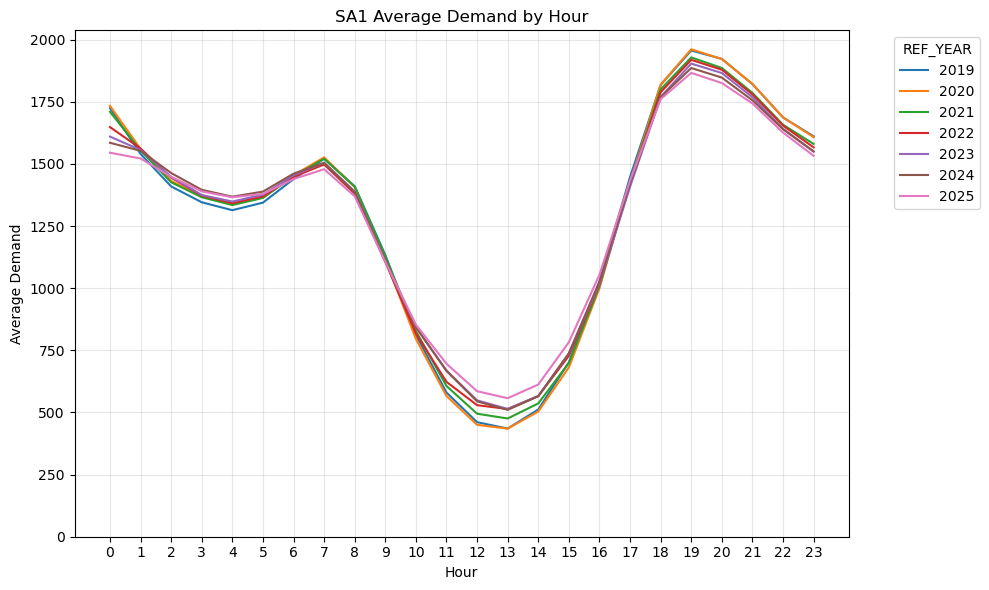

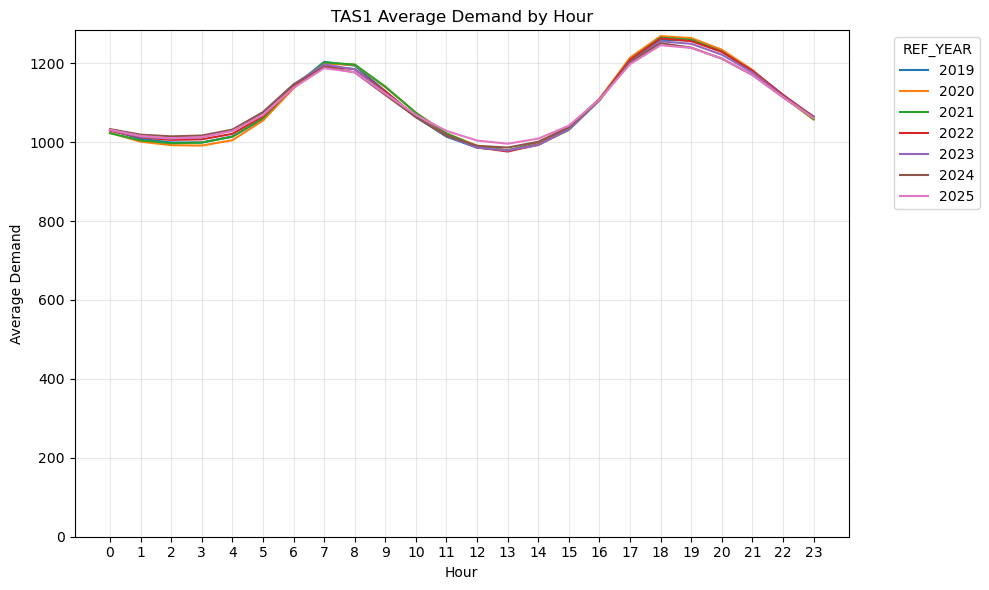

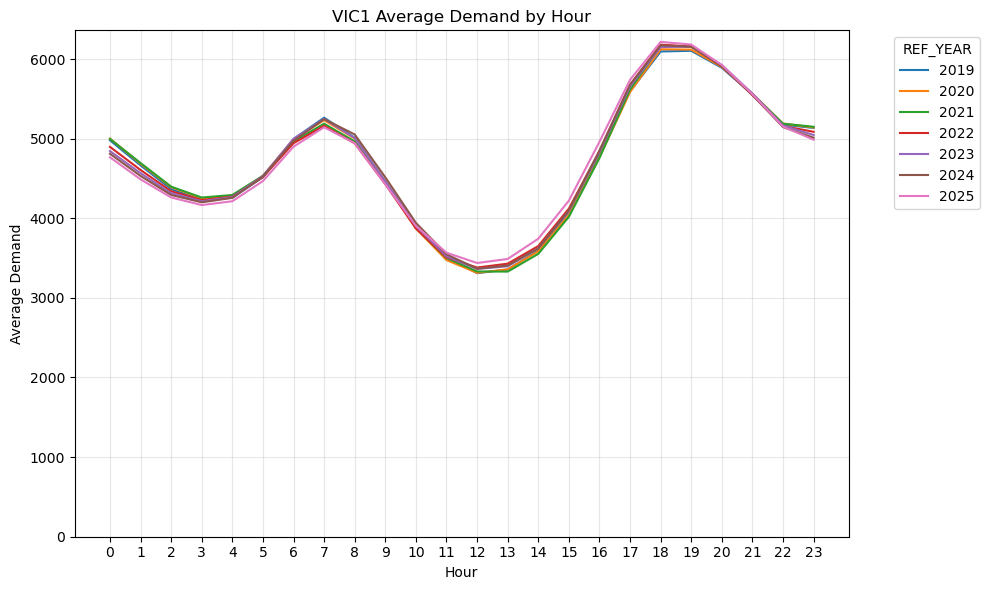

In [2]:
#check demand curves
import matplotlib.pyplot as plt

regions = ['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1']

df_demand = df_demand[df_demand['REF_YEAR'] != 2026]

# Average demand by year and hour
hourly_avg = (
    df_demand.groupby(['REF_YEAR', 'Hour'])[[f'{r}_DEM_GROSS' for r in regions]]
      .mean()
      .reset_index()
)

for region in regions:
    plt.figure(figsize=(10, 6))

    for year in sorted(hourly_avg['REF_YEAR'].unique()):
        data = hourly_avg[hourly_avg['REF_YEAR'] == year]

        plt.plot(
            data['Hour'],
            data[f'{region}_DEM_GROSS'],
            label=str(year)
        )

    plt.title(f'{region} Average Demand by Hour')
    plt.xlabel('Hour')
    plt.ylabel('Average Demand')
    plt.xticks(range(24))
    plt.grid(True, alpha=0.3)
    plt.legend(title='REF_YEAR', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

df = df_long[(df_long.REF_YEAR == 2025 ) & ( df_long.Month== 8) & (df_long.Day== 1)]

# Ensure datetime is a datetime type
df["INTERVAL_DATETIME"] = pd.to_datetime(df["INTERVAL_DATETIME"])

# Pivot so each region is a separate column
plot_df = df.pivot(
    index="INTERVAL_DATETIME",
    columns="REGIONID",
    values="DEMAND50"
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(ax=ax)

ax.set_xlabel("Datetime")
ax.set_ylabel("DEMAND50")
ax.set_title("Demand by Region")
ax.legend(title="Region")
plt.tight_layout()
plt.show()

